In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [7]:
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv('AirPassengers.csv')

In [12]:
data['Month'] = pd.to_datetime(data['Month']).dt.month

In [13]:
data

,Month,#Passengers
0,1,112
1,2,118
2,3,132
3,4,129
4,5,121
...,...,...
139,8,606
140,9,508
141,10,461
142,11,390


In [15]:
data.set_index('Month', inplace=True)

In [22]:
data.loc[7]

,#Passengers
Month,
7,148
7,170
7,199
7,230
7,264
7,302
7,364
7,413
7,465


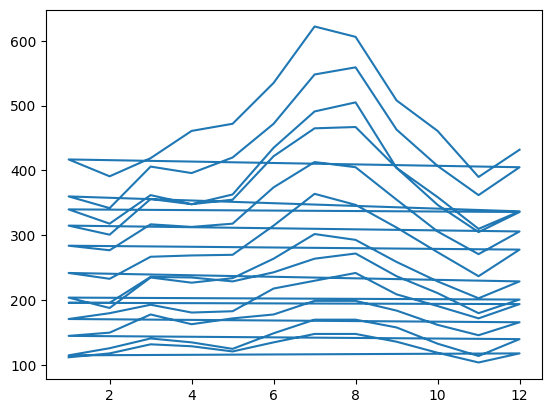

In [24]:
plt.plot(data, label = 'Pessengers')

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [26]:
model = Sequential()

In [30]:
model.add(LSTM(64, return_sequences=True, input_shape = (data.shape[1],1)))

C:\Users\memon\anaconda3\envs\vision\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
data.shape

(144, 1)

In [32]:
model.add(LSTM(32, return_sequences=False))

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,312 (114.50 KB)

 Trainable params: 29,312 (114.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.add(Dense(1))

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer='adam', loss = 'mse')

In [38]:
data

,#Passengers
Month,
1,112
2,118
3,132
4,129
5,121
...,...
8,606
9,508
10,461


In [39]:
x,y = [],[]

In [49]:
for i in range(len(data)- 12):
    x.append(data[i:i+12])
    y.append(data[i:i+12])

In [ ]:
np.array(x)
np.array(y)